# Analyzing India's Water Quality for Better Sanitation

**SDG 6: Clean Water and Sanitation**

This project analyses water quality across India using two datasets:
- **IndiaAffectedWaterQualityAreas.csv** — groundwater quality records (2009–2012) tracking contaminants such as Iron, Salinity, Fluoride, Arsenic, and Nitrate across 550,000+ habitations.
- **2022_lake_data.csv** — 2022 NWMP surface-water monitoring data for 639 lakes, ponds, tanks, and wetlands across 31 states/UTs, measuring Dissolved Oxygen, BOD, pH, Fecal Coliform, and more.

Together they allow assessment of both groundwater and surface-water pollution — two dimensions critical to SDG 6.1 (safe drinking water) and SDG 6.3 (reducing pollution and untreated wastewater).

**WHO / CPCB thresholds used throughout:**

| Parameter | Safe Limit |
|---|---|
| BOD | ≤ 3 mg/L |
| Dissolved Oxygen | ≥ 5 mg/L |
| pH | 6.5 – 8.5 |
| Fecal Coliform | ≤ 500 MPN/100 mL |
| Nitrate | ≤ 10 mg/L |


## 1. Import Libraries and Load Datasets

In [41]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

# ── Load datasets ─────────────────────────────────────────────────────────────
try:
    india_wq = pd.read_csv('IndiaAffectedWaterQualityAreas.csv',
                           encoding='ISO-8859-1', on_bad_lines='skip')
except TypeError:
    india_wq = pd.read_csv('IndiaAffectedWaterQualityAreas.csv',
                           encoding='ISO-8859-1', error_bad_lines=False)

lakes = pd.read_csv('2022_lake_data.csv')

print(f'Groundwater rows : {len(india_wq):,}')
print(f'Lake rows        : {len(lakes):,}')
print('\n--- Groundwater dataset (first 3 rows) ---')
display(india_wq.head(3))
print('\n--- Lake dataset (first 3 rows) ---')
display(lakes.head(3))

Groundwater rows : 550,242
Lake rows        : 648

--- Groundwater dataset (first 3 rows) ---


,State Name,District Name,Block Name,Panchayat Name,Village Name,Habitation Name,Quality Parameter,Year
0,ANDHRA PRADESH,EAST GODAVARI(04),PRATHIPADU(10),GOKAVARAM(04),VANTHADA(014 ),VANTHADA(0404410014010400),Salinity,1/4/2009
1,ANDHRA PRADESH,EAST GODAVARI(04),PRATHIPADU(10),GOKAVARAM(04),PANDAVULAPALEM(022 ),PANDAVULAPALEM(0404410022010400),Fluoride,1/4/2009
2,ANDHRA PRADESH,EAST GODAVARI(04),PRATHIPADU(10),GAJJANAPUDI(06),G. KOTHURU(023 ),G. KOTHURU(0404410023010600),Salinity,1/4/2009



--- Lake dataset (first 3 rows) ---


,STN Code,Name of Monitoring Location,Type Water Body,State Name,Min Temperature,Max Temperature,Min Dissolved Oxygen,Max Dissolved Oxygen,Min pH,Max pH,Min Conductivity,Max Conductivity,Min BOD,Max BOD,Min Nitrate N + Nitrite N,Max Nitrate N + Nitrite N,Min Fecal Coliform,Max Fecal Coliform,Min Total Coliform,Max Total Coliform
0,5159.0,"GARGEYAPURAM LAKE \nGARGEYAPURAM (V), \nKURNOO...",LAKE,ANDHRA \nPRADESH,22,27,3.9,6.5,7.1,7.9,374,1370,1.5,3.7,0.33,5.90,214,525,816,1733
1,4368.0,"KOLLERU LAKE, \nKOKKIRAYALANKA (V), \nKAILALUR...",LAKE,ANDHRA \nPRADESH,18,29,3.2,8.7,7.2,8.6,215,1800,1.6,6.1,0.69,2.79,7,21,210,460
2,2353.0,"KONDAKARLA-AAVA \nLAKE, KONDAKARLA, \nVISHAKHA...",LAKE,ANDHRA \nPRADESH,26,29,3.4,6.4,7.1,8.5,402,888,2.4,4.8,1.12,2.42,7,39,150,240


## 2. Data Cleaning

Key steps:
- Report and drop missing values.
- Normalise state names in the lake dataset (raw data has embedded newlines).
- Cast all numeric measurement columns.
- Derive **average** values (midpoint of Min/Max) for each parameter.

In [42]:
print('Missing values — Groundwater:')
print(india_wq.isnull().sum())

# Only drop rows missing the columns we actually use
india_wq = india_wq.dropna(subset=['State Name', 'Quality Parameter'])
india_wq['State Name'] = india_wq['State Name'].str.strip()
india_wq['Quality Parameter'] = india_wq['Quality Parameter'].str.strip()

# Year is stored as a date string like "1/4/2009" — extract the year from it
india_wq['Year'] = pd.to_datetime(india_wq['Year'], errors='coerce').dt.year
india_wq = india_wq.dropna(subset=['Year'])
india_wq['Year'] = india_wq['Year'].astype(int)

print(f'\nGroundwater rows after cleaning: {len(india_wq):,}')
print(india_wq['Quality Parameter'].value_counts())

Missing values — Groundwater:
State Name           0
District Name        0
Block Name           0
Panchayat Name       0
Village Name         0
Habitation Name      0
Quality Parameter    0
Year                 0
dtype: int64

Groundwater rows after cleaning: 550,242
Quality Parameter
Iron        302244
Salinity    108923
Fluoride    101041
Arsenic      25705
Nitrate      12329
Name: count, dtype: int64


In [43]:
# ── Lake dataset ──────────────────────────────────────────────────────────────
print('Missing values — Lake dataset:')
print(lakes.isnull().sum())

# Remove embedded newlines
lakes['State Name'] = lakes['State Name'].str.replace(r'\s+', ' ', regex=True).str.strip()
lakes['Name of Monitoring Location'] = (
    lakes['Name of Monitoring Location'].str.replace(r'\s+', ' ', regex=True).str.strip()
)

# Cast numeric columns
num_cols = [
    'Min Temperature', 'Max Temperature',
    'Min Dissolved Oxygen', 'Max Dissolved Oxygen',
    'Min pH', 'Max pH',
    'Min Conductivity', 'Max Conductivity',
    'Min BOD', 'Max BOD',
    'Min Nitrate N + Nitrite N', 'Max Nitrate N + Nitrite N',
    'Min Fecal Coliform', 'Max Fecal Coliform',
    'Min Total Coliform', 'Max Total Coliform',
]
for col in num_cols:
    if col in lakes.columns:
        lakes[col] = pd.to_numeric(lakes[col], errors='coerce')

# Drop rows missing core fields
lakes = lakes.dropna(subset=['State Name', 'Type Water Body', 'Min BOD', 'Max BOD',
                              'Min Dissolved Oxygen', 'Max Dissolved Oxygen'])

# Derived average columns
lakes['Avg BOD']            = (lakes['Min BOD'] + lakes['Max BOD']) / 2
lakes['Avg DO']             = (lakes['Min Dissolved Oxygen'] + lakes['Max Dissolved Oxygen']) / 2
lakes['Avg pH']             = (lakes['Min pH'] + lakes['Max pH']) / 2
lakes['Avg Fecal Coliform'] = (lakes['Min Fecal Coliform'].fillna(0) + lakes['Max Fecal Coliform'].fillna(0)) / 2
lakes['Avg Nitrate']        = (
    (lakes['Min Nitrate N + Nitrite N'].fillna(0) + lakes['Max Nitrate N + Nitrite N'].fillna(0)) / 2
)
lakes['Avg Temperature']    = (lakes['Min Temperature'].fillna(0) + lakes['Max Temperature'].fillna(0)) / 2

print(f'\nLake rows after cleaning: {len(lakes):,}')

Missing values — Lake dataset:
STN Code                        9
Name of Monitoring Location     0
Type Water Body                 9
State Name                      9
Min Temperature                15
Max Temperature                15
Min Dissolved Oxygen            9
Max Dissolved Oxygen            9
Min pH                          9
Max pH                          9
Min Conductivity               13
Max Conductivity               13
Min BOD                        10
Max BOD                        10
Min Nitrate N + Nitrite N      13
Max Nitrate N + Nitrite N      13
Min Fecal Coliform              9
Max Fecal Coliform              9
Min Total Coliform             10
Max Total Coliform             10
dtype: int64

Lake rows after cleaning: 635


### Descriptive Statistics — Lake Dataset

Note the large standard deviations for BOD and Fecal Coliform — driven by severely polluted outlier locations.

In [44]:
avg_cols = ['Avg BOD', 'Avg DO', 'Avg pH', 'Avg Fecal Coliform', 'Avg Nitrate', 'Avg Temperature']
lakes[avg_cols].describe().round(2)

,Avg BOD,Avg DO,Avg pH,Avg Fecal Coliform,Avg Nitrate,Avg Temperature
count,635.00,635.00,635.00,6.350000e+02,635.00,635.00
mean,9.20,5.07,7.53,8.336251e+06,4.04,24.59
std,15.09,2.08,0.42,1.683091e+08,6.97,4.57
min,1.00,0.30,4.85,0.000000e+00,0.00,0.00
25%,2.35,3.35,7.25,2.300000e+01,0.86,24.00
50%,4.00,5.50,7.50,1.635000e+02,1.92,25.00
75%,10.00,6.65,7.80,2.279750e+03,4.58,27.00
max,197.50,11.90,8.90,4.200002e+09,73.65,32.50


## 3. Groundwater: Quality Parameter Distribution

Iron contamination is the most prevalent issue (~55% of records), followed by Salinity and Fluoride. These contaminants cause long-term health problems including fluorosis, kidney damage, and gastrointestinal illness — directly impeding SDG 6.1 (universal access to safe drinking water).

Top 10 Most Affected States:
State Name
RAJASTHAN         131417
BIHAR              92336
ASSAM              79910
ORISSA             68620
KARNATAKA          30824
WEST BENGAL        30101
TRIPURA            26235
CHATTISGARH        25062
MADHYA PRADESH     14449
MAHARASHTRA        12480
Name: count, dtype: int64


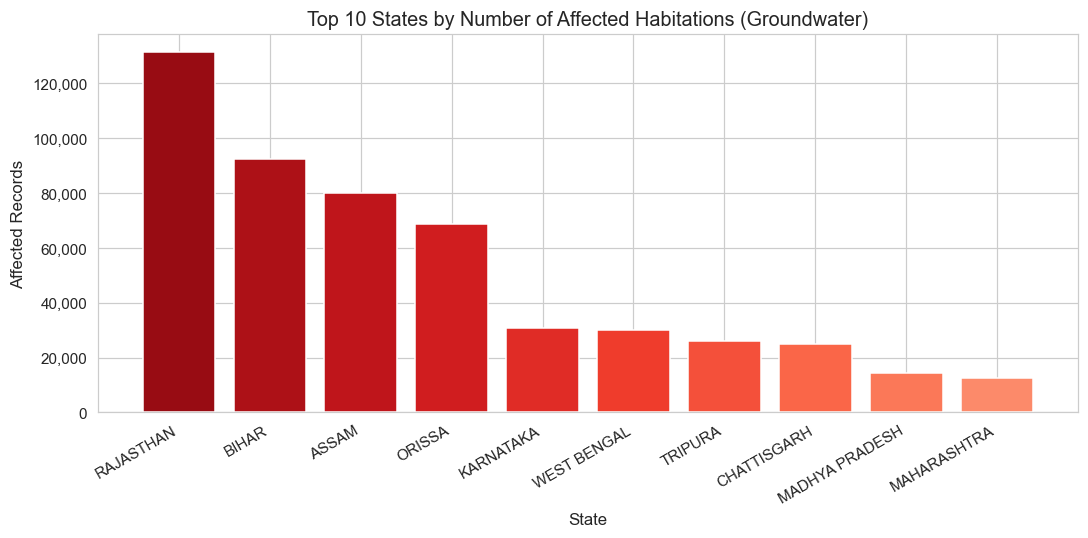

In [45]:
affected_states = india_wq['State Name'].value_counts().head(10)
print('Top 10 Most Affected States:')
print(affected_states)

colors_red = plt.cm.Reds(np.linspace(0.4, 0.9, len(affected_states)))[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(affected_states)), affected_states.values, color=colors_red)
ax.set_xticks(range(len(affected_states)))
ax.set_xticklabels(affected_states.index, rotation=30, ha='right')
ax.set_title('Top 10 States by Number of Affected Habitations (Groundwater)')
ax.set_xlabel('State')
ax.set_ylabel('Affected Records')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 4. Groundwater: Most Affected States

Rajasthan, Bihar, and Assam have the highest number of affected habitations. Rajasthan faces widespread fluoride and salinity issues; Bihar and Assam face chronic arsenic contamination — a public health crisis affecting tens of millions of people.

Top 10 Most Affected States:
State Name
RAJASTHAN         131417
BIHAR              92336
ASSAM              79910
ORISSA             68620
KARNATAKA          30824
WEST BENGAL        30101
TRIPURA            26235
CHATTISGARH        25062
MADHYA PRADESH     14449
MAHARASHTRA        12480
Name: count, dtype: int64


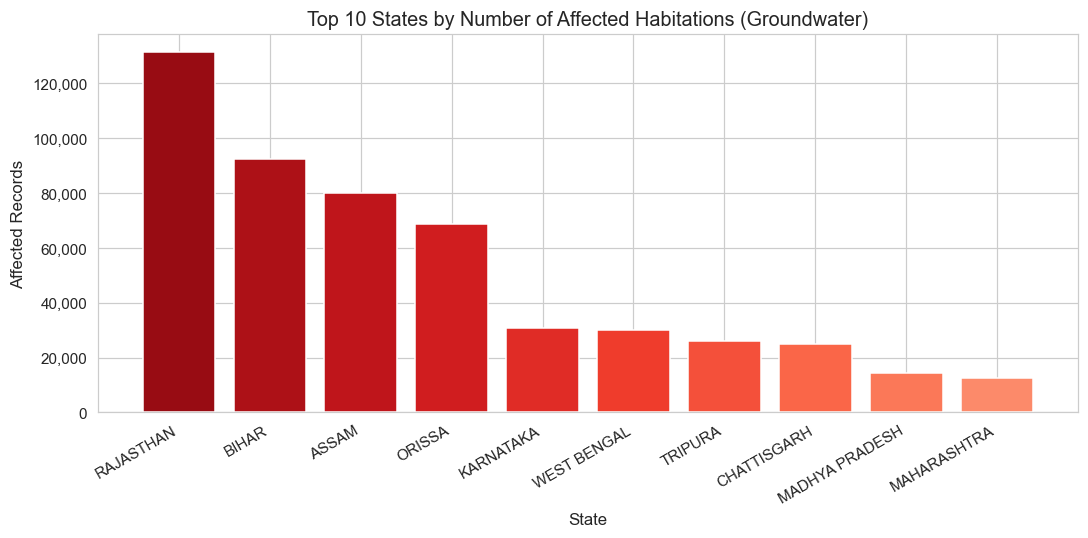

In [46]:
affected_states = india_wq['State Name'].value_counts().head(10)
print('Top 10 Most Affected States:')
print(affected_states)

colors_red = plt.cm.Reds(np.linspace(0.4, 0.9, len(affected_states)))[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(affected_states)), affected_states.values, color=colors_red)
ax.set_xticks(range(len(affected_states)))
ax.set_xticklabels(affected_states.index, rotation=30, ha='right')
ax.set_title('Top 10 States by Number of Affected Habitations (Groundwater)')
ax.set_xlabel('State')
ax.set_ylabel('Affected Records')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 5. Groundwater: Yearly Trend (2009–2012)

The number of recorded contamination events declined from 2009 to 2012. This likely reflects improvements in monitoring and water treatment rather than an absolute reduction in contamination. Sustained long-term monitoring is essential to verify genuine improvement — a core requirement of SDG 6 reporting.

Yearly Record Counts:
Year
2009    179999
2010    144582
2011    121501
2012    104160
Name: count, dtype: int64


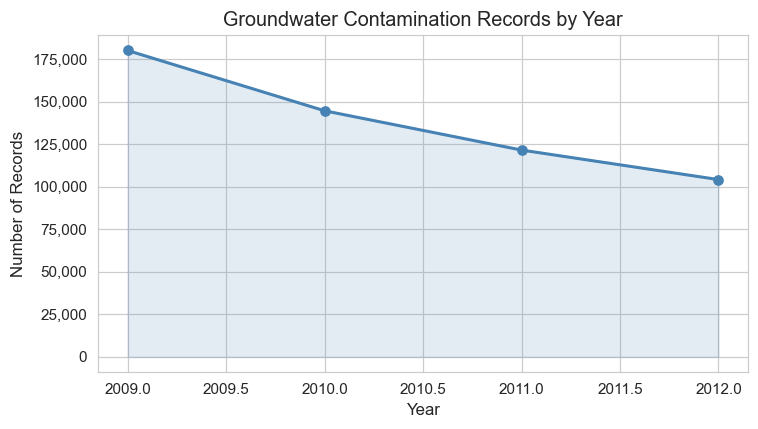

In [47]:
yearly_trends = india_wq['Year'].value_counts().sort_index()
print('Yearly Record Counts:')
print(yearly_trends)

x_years = list(yearly_trends.index.astype(int))
y_counts = list(yearly_trends.values)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_years, y_counts, marker='o', linewidth=2, color='steelblue')
ax.fill_between(x_years, y_counts, alpha=0.15, color='steelblue')
ax.set_title('Groundwater Contamination Records by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Records')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 6. Surface Water: pH Distribution

pH measures acidity/alkalinity. The WHO safe range is **6.5 – 8.5**. Most monitored lakes fall within the acceptable range, though several show elevated (alkaline) pH — often associated with algal blooms or industrial discharge.

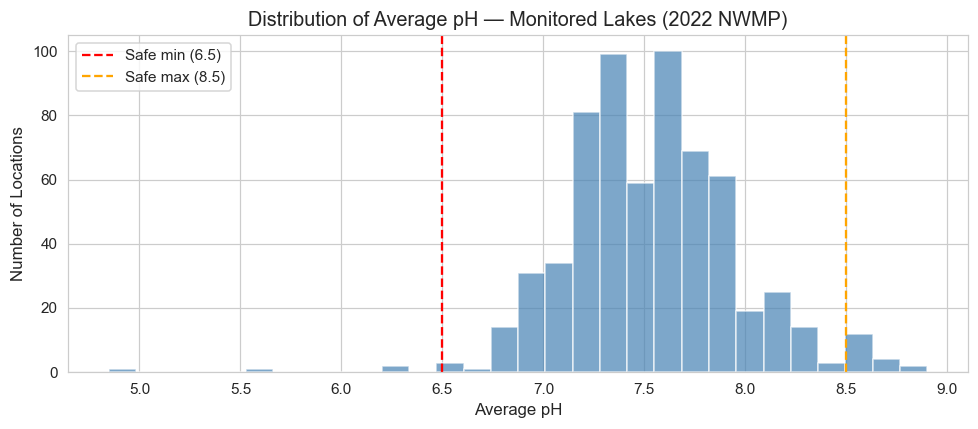

Locations with pH < 6.5 : 4
Locations with pH > 8.5 : 14


In [48]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lakes['Avg pH'].dropna(), bins=30, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(6.5, color='red',    linestyle='--', linewidth=1.5, label='Safe min (6.5)')
ax.axvline(8.5, color='orange', linestyle='--', linewidth=1.5, label='Safe max (8.5)')
ax.set_title('Distribution of Average pH — Monitored Lakes (2022 NWMP)')
ax.set_xlabel('Average pH')
ax.set_ylabel('Number of Locations')
ax.legend()
plt.tight_layout()
plt.show()

below_safe = (lakes['Avg pH'] < 6.5).sum()
above_safe = (lakes['Avg pH'] > 8.5).sum()
print(f'Locations with pH < 6.5 : {below_safe}')
print(f'Locations with pH > 8.5 : {above_safe}')

## 7. Surface Water: BOD vs Dissolved Oxygen — The Pollution Signal

**Biochemical Oxygen Demand (BOD)** measures organic pollution: the more organic waste, the more oxygen bacteria consume breaking it down. **Dissolved Oxygen (DO)** is what aquatic organisms need to survive.

They are inversely related: **high BOD depletes DO**. Locations in the bottom-right quadrant (high BOD, low DO) are critically polluted. The dashed lines mark CPCB safe thresholds.

Delhi's lakes average BOD **56 mg/L** — **19× the safe limit** — making them the most polluted in the dataset.

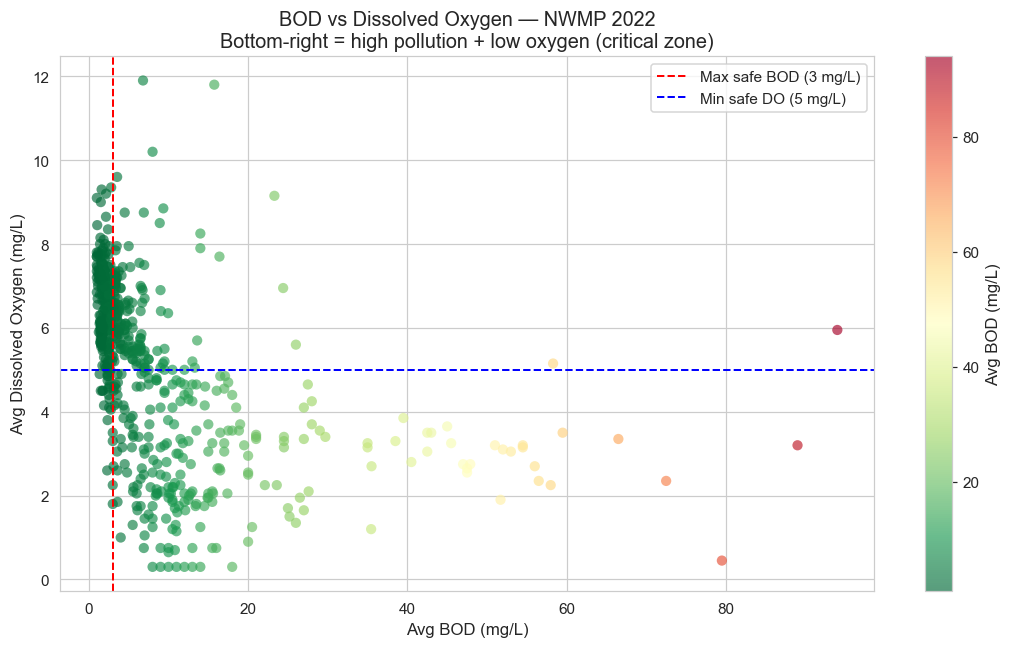


Top 5 most polluted locations by Avg BOD:


,Name of Monitoring Location,State Name,Avg BOD,Avg DO
0,MACHOHALLI LAKE,KARNATAKA,197.5,3.05
1,"ASANI KUNTA,BOLLARAM(V),JIN NARAM(M), SANGARED...",TELANGANA,138.0,0.30
2,AYYANAKERE LAKE,KARNATAKA,94.0,5.95
3,UTTARAHALLI DORAIKERE,KARNATAKA,89.0,3.20
4,DODDABIDARAKALLU LAKE,KARNATAKA,79.5,0.45


In [49]:
plot_df = lakes[lakes['Avg BOD'] <= 120].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    plot_df['Avg BOD'], plot_df['Avg DO'],
    c=plot_df['Avg BOD'], cmap='RdYlGn_r',
    alpha=0.65, edgecolors='none', s=45
)
plt.colorbar(sc, ax=ax, label='Avg BOD (mg/L)')
ax.axvline(3, color='red',  linestyle='--', linewidth=1.3, label='Max safe BOD (3 mg/L)')
ax.axhline(5, color='blue', linestyle='--', linewidth=1.3, label='Min safe DO (5 mg/L)')
ax.set_xlabel('Avg BOD (mg/L)')
ax.set_ylabel('Avg Dissolved Oxygen (mg/L)')
ax.set_title('BOD vs Dissolved Oxygen — NWMP 2022\n'
             'Bottom-right = high pollution + low oxygen (critical zone)')
ax.legend()
plt.tight_layout()
plt.show()

worst = lakes.nlargest(5, 'Avg BOD')[['Name of Monitoring Location', 'State Name', 'Avg BOD', 'Avg DO']]
print('\nTop 5 most polluted locations by Avg BOD:')
display(worst.reset_index(drop=True))

## 8. Surface Water: Average BOD by State

States ranked by average BOD across all monitored water bodies. Red bars exceed the safe limit (3 mg/L). States above this line show **systemic** pollution across their water bodies, not just isolated hotspots.

Delhi stands out dramatically — a direct consequence of untreated sewage entering urban water bodies.

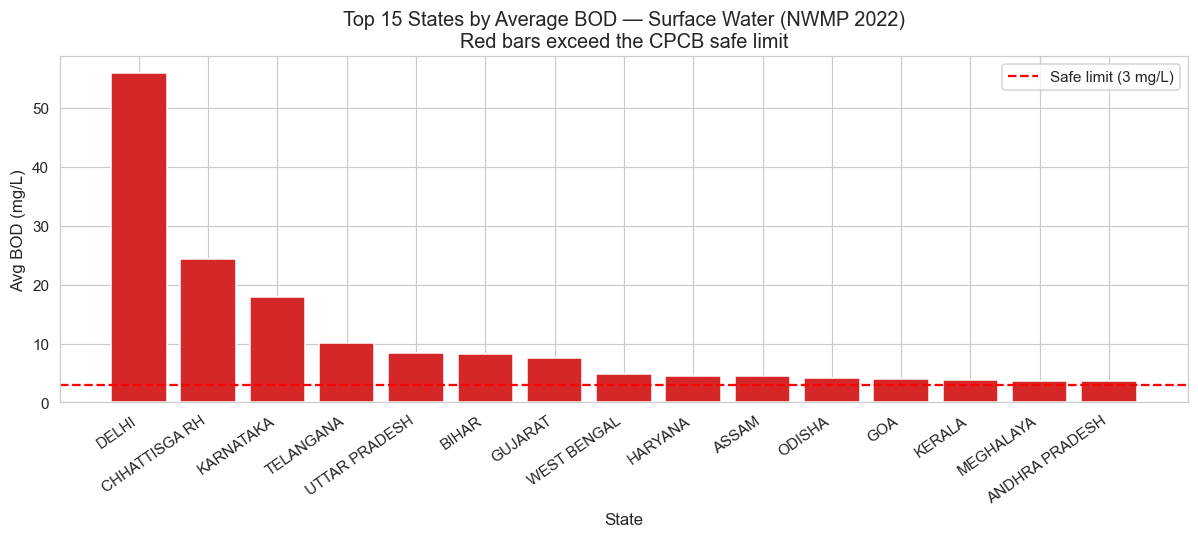

In [50]:
state_bod = (
    lakes.groupby('State Name')['Avg BOD']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

bar_colors = ['#d62728' if v > 3 else '#1f77b4' for v in state_bod['Avg BOD']]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(len(state_bod)), state_bod['Avg BOD'], color=bar_colors)
ax.set_xticks(range(len(state_bod)))
ax.set_xticklabels(state_bod['State Name'], rotation=35, ha='right')
ax.axhline(3, color='red', linestyle='--', linewidth=1.5, label='Safe limit (3 mg/L)')
ax.set_title('Top 15 States by Average BOD — Surface Water (NWMP 2022)\n'
             'Red bars exceed the CPCB safe limit')
ax.set_xlabel('State')
ax.set_ylabel('Avg BOD (mg/L)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Correlation Analysis — Surface Water Parameters

The correlation heatmap shows how parameters relate across all monitored locations:
- **BOD and Fecal Coliform** are positively correlated — both rise with sewage pollution.
- **BOD and DO** are negatively correlated — as organic load rises, oxygen is depleted.
- **pH** shows weak correlation with most parameters.

These relationships support the conclusion that **untreated sewage** is the dominant driver of surface-water degradation.

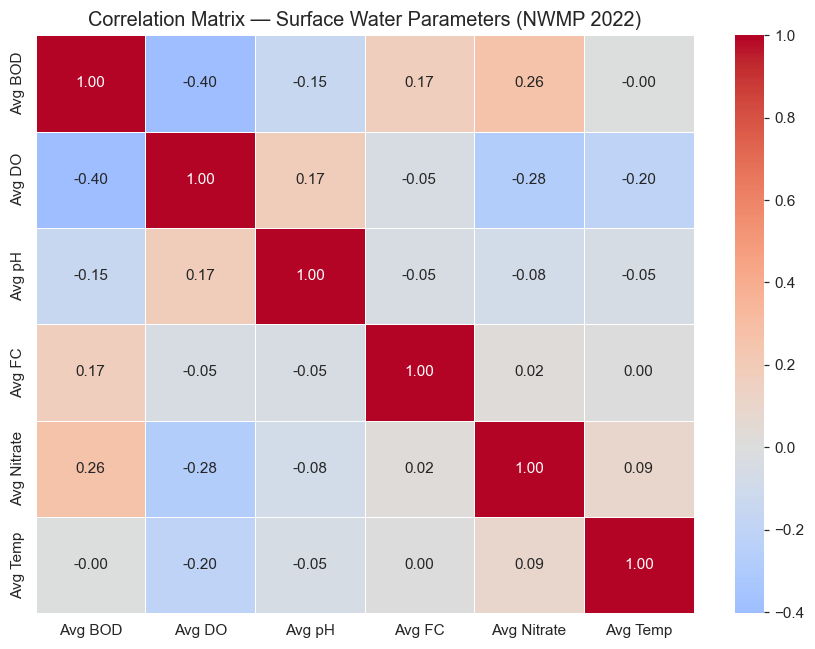

In [51]:
corr_cols = ['Avg BOD', 'Avg DO', 'Avg pH', 'Avg Fecal Coliform', 'Avg Nitrate', 'Avg Temperature']
corr_labels = ['Avg BOD', 'Avg DO', 'Avg pH', 'Avg FC', 'Avg Nitrate', 'Avg Temp']

corr_matrix = lakes[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    xticklabels=corr_labels,
    yticklabels=corr_labels,
    linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix — Surface Water Parameters (NWMP 2022)')
plt.tight_layout()
plt.show()

## 10. Water Quality Index (WQI) — Weighted Score

A WQI aggregates multiple parameters into a single score. We use a **weighted formula** that prioritises parameters most critical to human health (following CPCB guidance), rather than averaging all parameters equally:

| Parameter | Weight | Rationale |
|---|---|---|
| BOD | 0.35 | Primary indicator of organic/sewage pollution |
| Dissolved Oxygen | 0.25 | Essential for aquatic life; low DO = dead zone |
| Fecal Coliform | 0.25 | Direct indicator of faecal contamination |
| pH | 0.10 | Affects usability; usually within range |
| Nitrate | 0.05 | Relevant but less acute |

Each parameter is normalised relative to its safe limit. **WQI > 1 means the location exceeds safe limits** on average.

In [52]:
BOD_SAFE = 3.0
DO_MIN   = 5.0
FC_SAFE  = 500.0
PH_IDEAL = 7.5
NO3_SAFE = 10.0

df = lakes.copy()

df['WQI_BOD'] = df['Avg BOD'] / BOD_SAFE
df['WQI_DO']  = DO_MIN / df['Avg DO'].replace(0, np.nan)
df['WQI_FC']  = df['Avg Fecal Coliform'] / FC_SAFE
df['WQI_pH']  = (df['Avg pH'] - PH_IDEAL).abs() / 1.0
df['WQI_NO3'] = df['Avg Nitrate'] / NO3_SAFE

weights = {'WQI_BOD': 0.35, 'WQI_DO': 0.25, 'WQI_FC': 0.25, 'WQI_pH': 0.10, 'WQI_NO3': 0.05}
df['WQI'] = sum(df[col] * w for col, w in weights.items())

def wqi_grade(wqi):
    if pd.isna(wqi):  return 'Unknown'
    if wqi <= 0.5:    return 'A - Excellent'
    if wqi <= 1.0:    return 'B - Acceptable'
    if wqi <= 2.0:    return 'C - Marginal'
    if wqi <= 5.0:    return 'D - Poor'
    return               'E - Critical'

df['WQ Grade'] = df['WQI'].apply(wqi_grade)

print('WQI Summary Statistics:')
print(df['WQI'].describe().round(3))
print('\nGrade distribution:')
print(df['WQ Grade'].value_counts())

WQI Summary Statistics:
count        635.000
mean        4169.628
std        84154.876
min            0.284
25%            0.612
50%            1.100
75%            3.066
max      2100006.531
Name: WQI, dtype: float64

Grade distribution:
WQ Grade
B - Acceptable    205
D - Poor          121
E - Critical      111
C - Marginal      101
A - Excellent      97
Name: count, dtype: int64


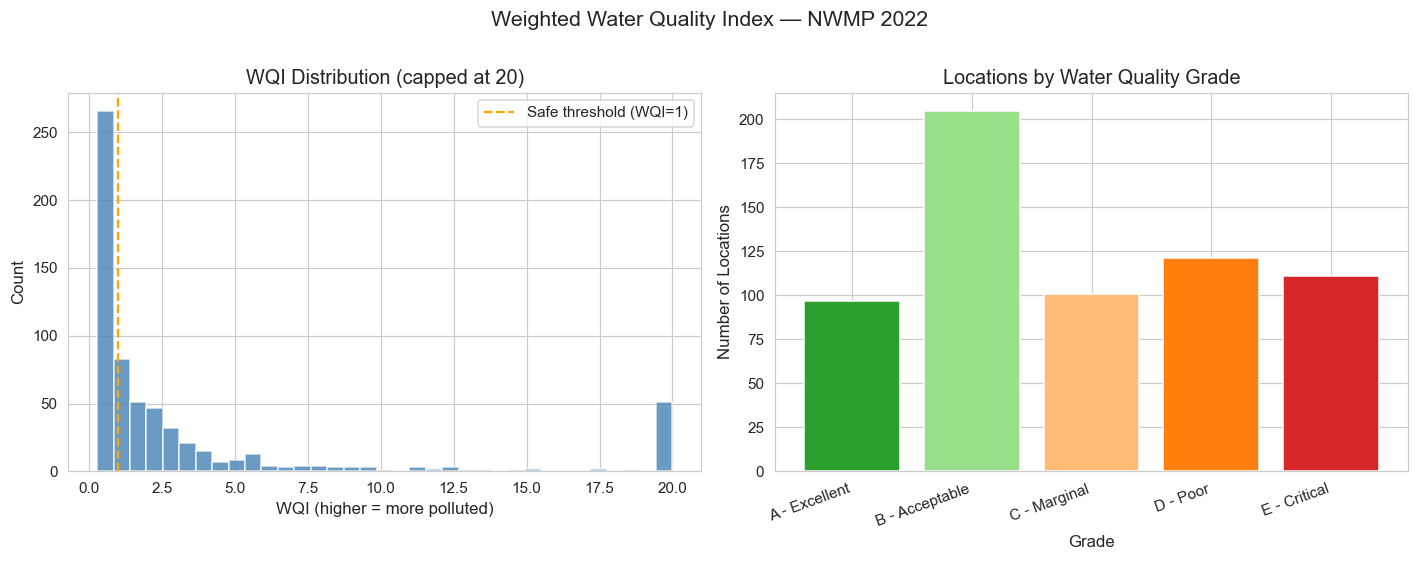

In [53]:
grade_order  = ['A - Excellent', 'B - Acceptable', 'C - Marginal', 'D - Poor', 'E - Critical']
grade_colors = ['#2ca02c', '#98df8a', '#ffbb78', '#ff7f0e', '#d62728']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram (cap at 20 for readability)
axes[0].hist(df['WQI'].clip(upper=20).dropna(), bins=35, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(1.0, color='orange', linestyle='--', linewidth=1.5, label='Safe threshold (WQI=1)')
axes[0].set_title('WQI Distribution (capped at 20)')
axes[0].set_xlabel('WQI (higher = more polluted)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Grade bar chart
grade_counts = df['WQ Grade'].value_counts().reindex(grade_order).fillna(0)
color_list   = [grade_colors[i] for i, g in enumerate(grade_order)]
axes[1].bar(range(len(grade_counts)), grade_counts.values, color=color_list)
axes[1].set_xticks(range(len(grade_counts)))
axes[1].set_xticklabels(grade_counts.index, rotation=20, ha='right')
axes[1].set_title('Locations by Water Quality Grade')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Number of Locations')

plt.suptitle('Weighted Water Quality Index — NWMP 2022', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 11. WQI by State — Best and Worst Performers

Aggregating WQI by state reveals systemic differences in surface-water health. High-WQI states need urgent remediation investment; low-WQI states offer case studies in effective water management.

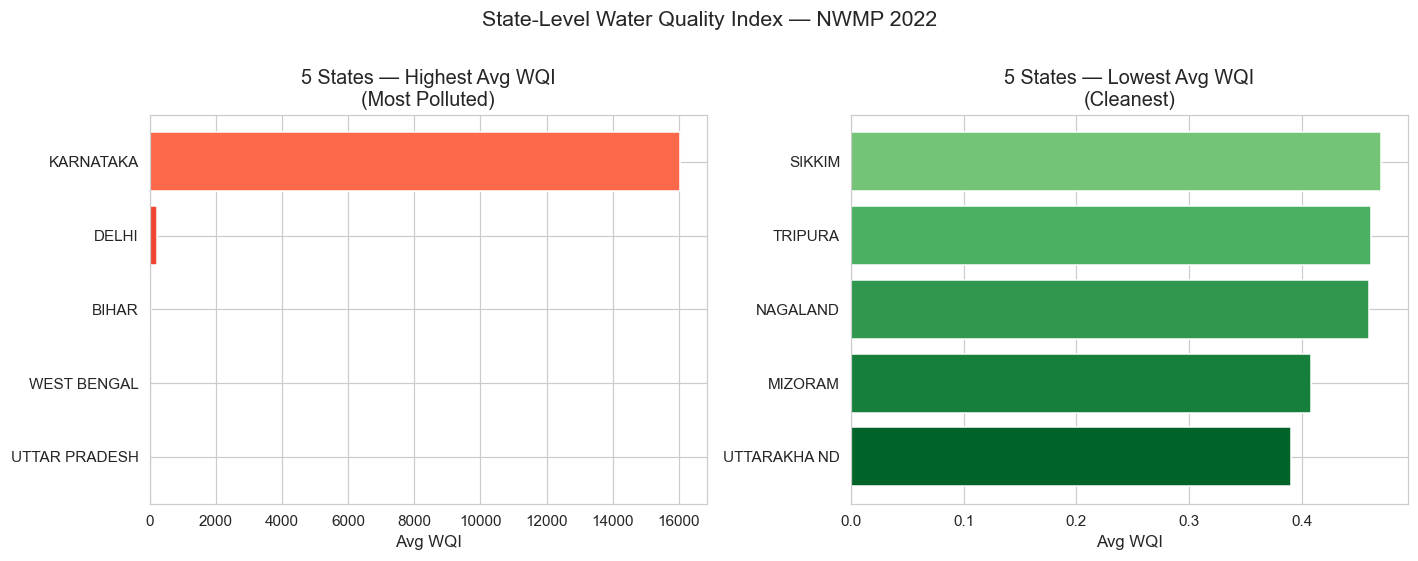

Worst 5 states (avg WQI):


,State Name,Avg WQI
0,KARNATAKA,16036.547488
1,DELHI,218.566390
2,BIHAR,41.009426
3,WEST BENGAL,7.642255
4,UTTAR PRADESH,4.602668



Best 5 states (avg WQI):


,State Name,Avg WQI
0,UTTARAKHA ND,0.390157
1,MIZORAM,0.408486
2,NAGALAND,0.459887
3,TRIPURA,0.461501
4,SIKKIM,0.470772


In [54]:
state_wqi = (
    df.groupby('State Name')['WQI']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'WQI': 'Avg WQI'})
)

worst5 = state_wqi.head(5)
best5  = state_wqi.tail(5).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_w = plt.cm.Reds(np.linspace(0.5, 0.9, len(worst5)))[::-1]
axes[0].barh(worst5['State Name'][::-1], worst5['Avg WQI'][::-1], color=colors_w)
axes[0].set_title('5 States — Highest Avg WQI\n(Most Polluted)')
axes[0].set_xlabel('Avg WQI')

colors_b = plt.cm.Greens(np.linspace(0.5, 0.9, len(best5)))[::-1]
axes[1].barh(best5['State Name'], best5['Avg WQI'], color=colors_b)
axes[1].set_title('5 States — Lowest Avg WQI\n(Cleanest)')
axes[1].set_xlabel('Avg WQI')

plt.suptitle('State-Level Water Quality Index — NWMP 2022', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Worst 5 states (avg WQI):')
display(worst5.reset_index(drop=True))
print('\nBest 5 states (avg WQI):')
display(best5.reset_index(drop=True))

## 12. Cross-Dataset: States at Risk in Both Groundwater and Surface Water

A state appearing in both the top groundwater-contamination list **and** with high surface-water BOD faces a double burden of water insecurity. Identifying these states helps prioritise integrated interventions.

In [55]:
gw_top = set(india_wq['State Name'].str.upper().value_counts().head(10).index)

sw_high_bod = set(
    lakes.groupby('State Name')['Avg BOD']
    .mean()
    .loc[lambda x: x > 3]
    .index.str.upper()
)

double_burden = gw_top & sw_high_bod

print('States in TOP 10 for groundwater contamination AND avg surface-water BOD > 3 mg/L:')
if double_burden:
    for s in sorted(double_burden):
        print(f'  ⚠  {s}')
else:
    print('  (No exact matches — note: state name formatting may differ between the two datasets)')

print('\nGroundwater top 10:')
print(sorted(gw_top))
print('\nSurface-water high-BOD states:')
print(sorted(sw_high_bod))

States in TOP 10 for groundwater contamination AND avg surface-water BOD > 3 mg/L:
  ⚠  ASSAM
  ⚠  BIHAR
  ⚠  KARNATAKA
  ⚠  WEST BENGAL

Groundwater top 10:
['ASSAM', 'BIHAR', 'CHATTISGARH', 'KARNATAKA', 'MADHYA PRADESH', 'MAHARASHTRA', 'ORISSA', 'RAJASTHAN', 'TRIPURA', 'WEST BENGAL']

Surface-water high-BOD states:
['ANDHRA PRADESH', 'ASSAM', 'BIHAR', 'CHHATTISGA RH', 'DELHI', 'GOA', 'GUJARAT', 'HARYANA', 'KARNATAKA', 'KERALA', 'MANIPUR', 'MEGHALAYA', 'ODISHA', 'TELANGANA', 'UTTAR PRADESH', 'WEST BENGAL']


In [56]:
# ── Live-computed summary stats (referenced in the conclusion below) ───────────
pct_exceed_bod = (lakes['Avg BOD'] > BOD_SAFE).mean() * 100
worst_state    = lakes.groupby('State Name')['Avg BOD'].mean().idxmax()
worst_bod      = lakes.groupby('State Name')['Avg BOD'].mean().max()
multiplier     = worst_bod / BOD_SAFE

iron_pct = (
    india_wq['Quality Parameter'].str.lower().str.contains('iron').sum()
    / len(india_wq) * 100
)

print(f'% locations exceeding BOD safe limit : {pct_exceed_bod:.1f}%')
print(f'Most polluted state (avg BOD)         : {worst_state}')
print(f'Avg BOD there                         : {worst_bod:.1f} mg/L ({multiplier:.0f}x the safe limit)')
print(f'Iron share of groundwater records     : {iron_pct:.1f}%')

% locations exceeding BOD safe limit : 61.1%
Most polluted state (avg BOD)         : DELHI
Avg BOD there                         : 56.0 mg/L (19x the safe limit)
Iron share of groundwater records     : 54.9%


## 13. Conclusion and SDG 6 Implications

### Key Findings

1. **Iron contamination dominates groundwater risk.** Over 55% of all recorded contamination events involve iron, with Rajasthan, Bihar, and Assam most affected. Arsenic contamination in Bihar and Assam poses acute risks linked to cancer and organ damage.

2. **Organic pollution is the primary surface-water threat.** More than **61%** of NWMP-monitored water bodies exceed the CPCB BOD safe limit (3 mg/L), indicating widespread sewage and organic waste discharge.

3. **Delhi's lakes are in a critical state.** Average BOD is **56 mg/L — 19× the safe limit**. Dissolved oxygen is dangerously low, rendering these water bodies hostile to aquatic life.

4. **BOD and Dissolved Oxygen are inversely correlated.** High organic load depletes oxygen, compressing toxicity and hypoxia into the same water bodies — confirmed by the scatter plot in Section 7.

5. **Some states face a double burden.** States appearing in both the high-groundwater-contamination list and the high-surface-water-BOD list have systemic infrastructure deficits driving water insecurity across multiple dimensions.

### SDG 6 Alignment

| SDG Target | Finding | Implication |
|---|---|---|
| **6.1** Safe drinking water | Widespread iron/fluoride/arsenic in groundwater | Millions lack access to safe drinking water |
| **6.3** Reduce pollution | 61%+ of surface sites exceed BOD safe limit | Untreated sewage discharge must be urgently addressed |
| **6.6** Protect ecosystems | Low DO in high-BOD water bodies | Lake ecosystems are collapsing in urban areas |

### Recommendations

- **Prioritise sewage treatment infrastructure** in Delhi, Karnataka, and Chhattisgarh — the states with the highest surface-water BOD.
- **Target arsenic and iron removal** programmes in Bihar, Assam, and Rajasthan.
- **Use the WQI score** as a trackable KPI for state-level SDG 6 reporting — a single number integrating health-critical parameters.
- **Extend NWMP monitoring** to under-represented states to close data gaps.
